In [24]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append(f"./../")

from src.graphs import StaticGraph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{('10', '11'), ('00', '11'), ('01', '11')}


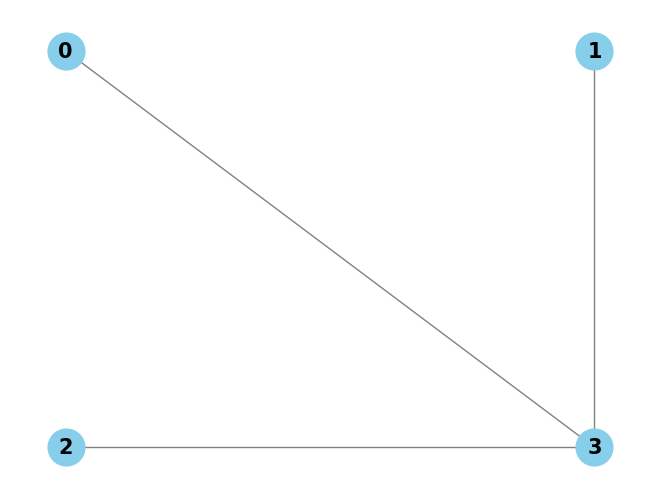

None

{('00', '10'), ('00', '11'), ('01', '11')}


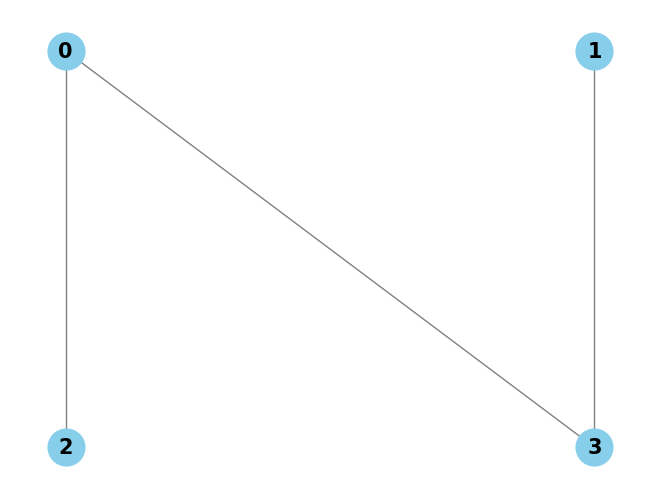

None

{('00', '10'), ('00', '11'), ('01', '11'), ('10', '11')}


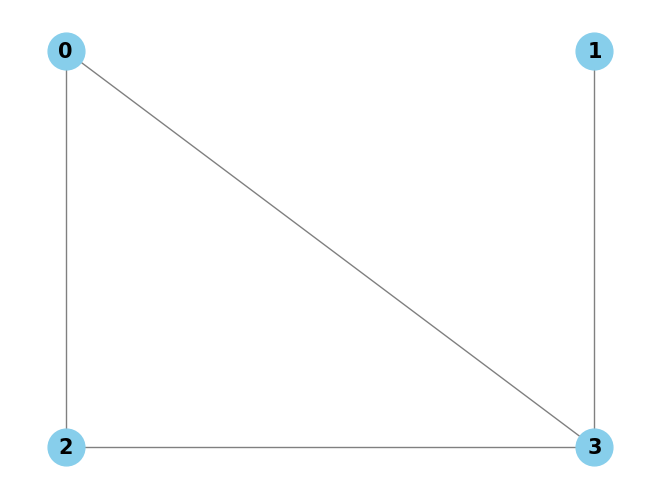

None

{('00', '10'), ('00', '11'), ('01', '10'), ('01', '11')}


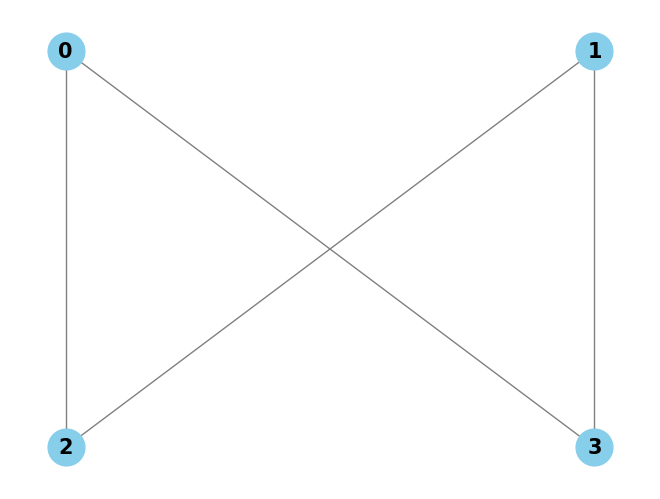

None

{('10', '11'), ('00', '11'), ('01', '11'), ('00', '10'), ('01', '10')}


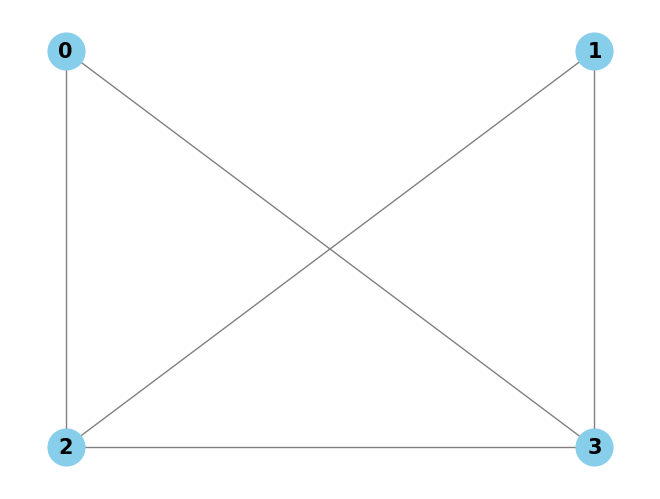

None

{('10', '11'), ('00', '01'), ('00', '11'), ('01', '11'), ('00', '10'), ('01', '10')}


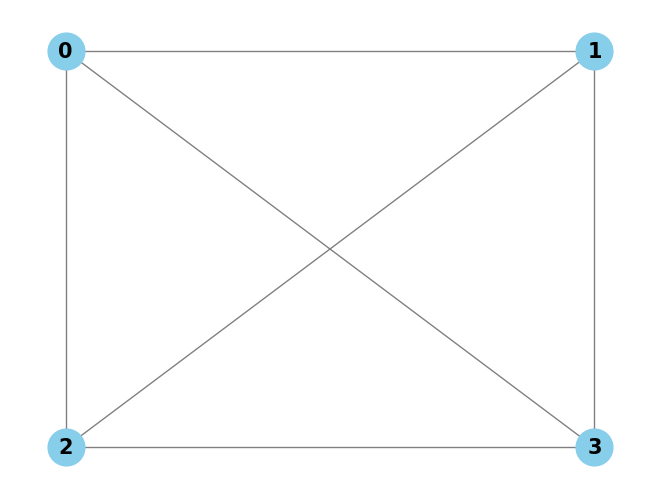

None

In [25]:
import networkx as nx

def graph_to_bitstring_edges(graph):
    # Number of nodes in the graph
    num_nodes = len(graph.nodes)

    # Determine how many bits are needed for each node (based on the number of nodes)
    num_bits = len(bin(num_nodes - 1)) - 2  # bin(x) gives '0bxxx', so we subtract 2

    # Create a mapping of node to bit string
    node_to_bitstring = {node: format(node, f'0{num_bits}b') for node in graph.nodes}

    # Convert edges to the new format
    edges_bitstring = {(node_to_bitstring[u], node_to_bitstring[v]) for u, v in graph.edges}

    return edges_bitstring

# Test on the graph from your previous code
g6 = f'./../data/graphs/graph4c.g6'

graph_edges =[]

# Open and read the .g6 file line by line
with open(g6, 'r') as file:
    for line in file:
        g6_string = line.strip()
        try:
            # Convert the graph6 string into a NetworkX graph
            graph = nx.from_graph6_bytes(g6_string.encode('utf-8'))
            
            # Convert the graph edges to bit string format
            bitstring_edges = graph_to_bitstring_edges(graph)
            
            # Output the result
            print(bitstring_edges)
            graph_edges.append(bitstring_edges)
            G = StaticGraph(bitstring_edges)
            display(G.draw())  
        except nx.NetworkXError as e:
            print(f"Error: {e}")


In [26]:
graph_edges = [{('000','010'),
         ('000','001'),
         ('001','011'),
         ('100','110'),
         ('110','111'),
         ('101','111')}]

Graph 1:
  Dynamic Quantum Walk: CX=40, U3=39, Depth=61
  Pauli Decomposition: CX=17, U3=28, Depth=33



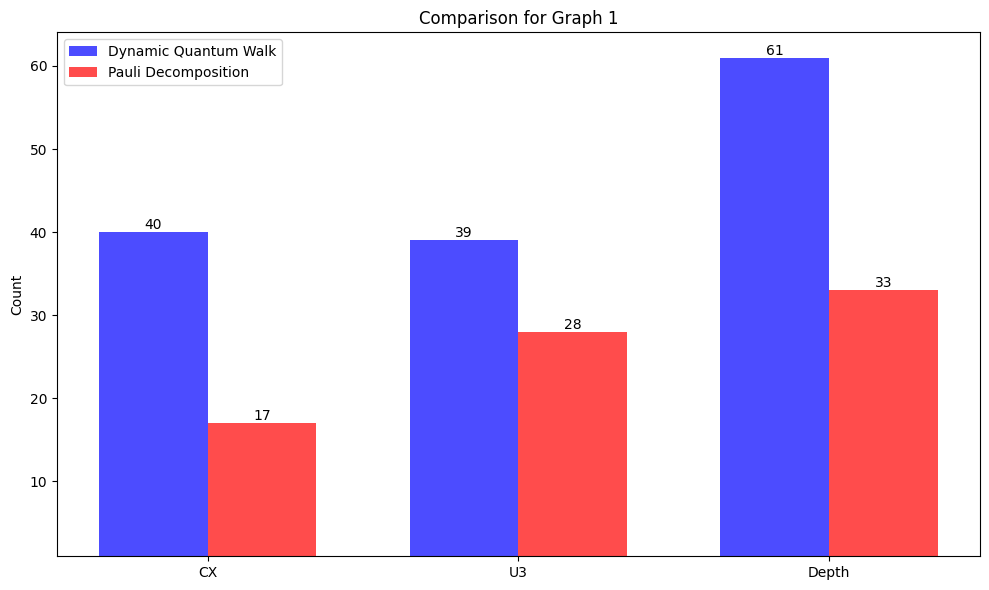

In [27]:
import matplotlib.pyplot as plt
from src.graphs import StaticGraph, DynamicGraph, IntersectingEdgesGraph, MultiEdgeGraph
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator, SparsePauliOp, Pauli
from scipy.linalg import expm
import numpy as np
import itertools

def unitary_to_pauli(U):
    n = int(np.log2(U.shape[0]))
    dim = 2**n
    pauli_strings = []
    coeffs = []
    for pauli_string in [''.join(p) for p in itertools.product('IXYZ', repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ U) / dim
        if not np.isclose(coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(coeff)
    return SparsePauliOp(pauli_strings, coeffs)

def construct_time_evolution_matrix(pauli_terms, delta_t):
    matrix = Operator(pauli_terms).data
    exponent = -1j * delta_t * matrix
    return Operator(expm(exponent))

def count_gates_dynamic_walk(edges, T, delta_t):
    G = StaticGraph(edges)
    graph_sequence = [(G, T)]
    dyn_G = DynamicGraph(graph_sequence)
    intersecting_G = IntersectingEdgesGraph(edges)
    graph_sequence = [(graph, delta_t) for graph in intersecting_G.subgraphs]
    dyn_G_approx = DynamicGraph(graph_sequence)
    
    big_qc = QuantumCircuit(G.n_qubits)
    for sq in dyn_G_approx.graph_sequence:
        G = MultiEdgeGraph(sq[0].edges)
        sub_qc = G.get_qc(simplified=True)
        big_qc = big_qc.compose(sub_qc)
    
    transpiled_qc = transpile(big_qc, basis_gates=['cx', 'u3'], optimization_level=3)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()

def count_gates_pauli_decomp(edges, delta_t):
    G = StaticGraph(edges)
    pauli_terms = unitary_to_pauli(G.get_adj_mat())
    evo_matrix_from_pauli = construct_time_evolution_matrix(pauli_terms, delta_t)
    
    qc = QuantumCircuit(G.n_qubits)
    qc.unitary(evo_matrix_from_pauli, range(G.n_qubits), label='Evo')
    
    transpiled_qc = transpile(qc, basis_gates=['cx', 'u3'], optimization_level=3)
    gate_counts = transpiled_qc.count_ops()
    return gate_counts.get('cx', 0), gate_counts.get('u3', 0), transpiled_qc.depth()

T = 200
delta_t = 0.1

results = []

for i, edges in enumerate(graph_edges):
    dynamic_cx, dynamic_u3, dynamic_depth = count_gates_dynamic_walk(edges, T, delta_t)
    pauli_cx, pauli_u3, pauli_depth = count_gates_pauli_decomp(edges, delta_t)
    
    results.append({
        'Dynamic': {'CX': dynamic_cx, 'U3': dynamic_u3, 'Depth': dynamic_depth},
        'Pauli': {'CX': pauli_cx, 'U3': pauli_u3, 'Depth': pauli_depth}
    })
    
    print(f"Graph {i+1}:")
    print(f"  Dynamic Quantum Walk: CX={dynamic_cx}, U3={dynamic_u3}, Depth={dynamic_depth}")
    print(f"  Pauli Decomposition: CX={pauli_cx}, U3={pauli_u3}, Depth={pauli_depth}")
    print()

# Create a separate plot for each graph
for i, result in enumerate(results):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    metrics = ['CX', 'U3', 'Depth']
    x = np.arange(len(metrics))
    width = 0.35
    
    dynamic_values = [result['Dynamic'][m] for m in metrics]
    pauli_values = [result['Pauli'][m] for m in metrics]
    
    ax.bar(x - width/2, dynamic_values, width, label='Dynamic Quantum Walk', color='blue', alpha=0.7)
    ax.bar(x + width/2, pauli_values, width, label='Pauli Decomposition', color='red', alpha=0.7)
    
    ax.set_ylabel('Count')
    ax.set_title(f'Comparison for Graph {i+1}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    
    # Add value labels on the bars
    for j, v in enumerate(dynamic_values):
        ax.text(j - width/2, v, str(v), ha='center', va='bottom')
    for j, v in enumerate(pauli_values):
        ax.text(j + width/2, v, str(v), ha='center', va='bottom')
    
    # Set y-axis to log scale
    #ax.set_yscale('log')
    
    # Adjust y-axis to start from 1
    ax.set_ylim(bottom=1)
    
    plt.tight_layout()
    plt.show()